In [ ]:
import statistics as stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("./data/processed/shopping_cleaned.csv" , encoding="latin-1")
data.head(20)

,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method
0,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,Present,Standard,No,0,Credit Card
1,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,Missing,Standard,No,0,Credit Card
2,26.0,Male,Leggings,23.595139,Nevada,XL,Brown,Winter,Missing,Standard,No,3,Credit Card
3,43.0,Male,Dress,34.079015,California,M,Terra cotta,Fall,Present,Standard,No,0,Credit Card
4,29.0,Male,Shorts,23.796439,Minnesota,M,Lavender,Summer,Present,Express,No,0,Credit Card
5,25.0,Female,Jacket,31.595005,Washington,M,Mauve,Fall,Present,Standard,No,4,Credit Card
6,39.0,Female,Shorts,32.374104,Colorado,M,Fuchsia,Summer,Missing,Standard,No,3,Credit Card
7,45.0,Female,Jacket,35.548978,Florida,M,Brown,Winter,Missing,Standard,No,10,Credit Card
8,23.0,Male,Backpack,34.437918,Texas,M,Brown,Winter,Missing,Standard,No,2,Credit Card
9,27.0,Female,Handbag,29.430620,Virginia,XL,Black,Summer,Missing,Standard,No,2,Credit Card


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3158 non-null   float64
 1   Gender                 3158 non-null   str    
 2   Item Purchased         3158 non-null   str    
 3   Purchase Amount (USD)  3158 non-null   float64
 4   Location               3158 non-null   str    
 5   Size                   3158 non-null   str    
 6   Color                  3158 non-null   str    
 7   Season                 3158 non-null   str    
 8   Review Rating          3158 non-null   str    
 9   Shipping Type          3158 non-null   str    
 10  Promo Code Used        3158 non-null   str    
 11  Previous Purchases     3158 non-null   int64  
 12  Payment Method         3158 non-null   str    
dtypes: float64(2), int64(1), str(10)
memory usage: 320.9 KB


In [4]:
data.describe()

,Age,Purchase Amount (USD),Previous Purchases
count,3158.000000,3158.000000,3158.000000
mean,34.185244,38.812750,5.860988
std,10.578195,11.525595,5.844408
min,18.000000,11.946095,0.000000
25%,26.000000,29.419108,1.000000
50%,33.000000,37.126663,4.000000
75%,41.000000,48.974363,9.000000
max,73.000000,68.327455,20.000000


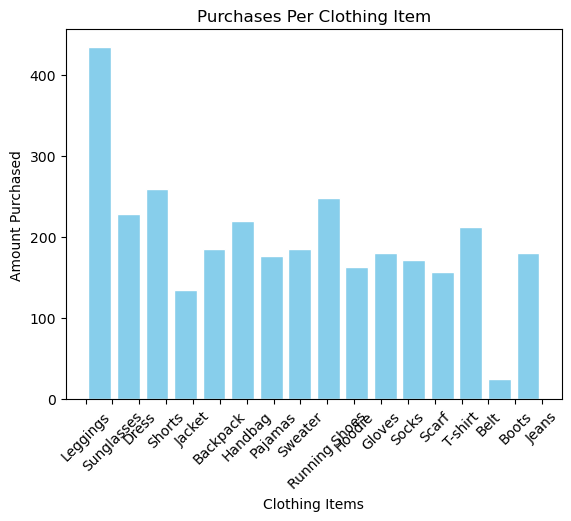

In [21]:
plt.hist(data['Item Purchased'], bins='auto', rwidth=0.8, edgecolor='white', color='skyblue')

plt.title('Purchases Per Clothing Item')
plt.xlabel('Clothing Items')
plt.xticks(rotation=45)
plt.ylabel('Amount Purchased')
# plt.figure(figsize=(12, 6))
plt.show()


In [28]:
data.pivot_table(values= 'Purchase Amount (USD)', index = 'Gender', columns='Item Purchased', aggfunc='mean')


Item Purchased,Backpack,Belt,Boots,Dress,Gloves,Handbag,Hoodie,Jacket,Jeans,Leggings,Pajamas,Running Shoes,Scarf,Shorts,Socks,Sunglasses,Sweater,T-shirt
Gender,,,,,,,,,,,,,,,,,,
Female,40.089948,36.681531,38.553699,39.912126,37.812172,40.688888,39.143467,38.479573,37.950174,41.081860,39.692138,37.844461,38.501344,38.886435,37.492446,39.593605,38.468843,38.185758
Male,39.371235,44.263723,37.958307,38.944671,40.076318,39.192158,36.768222,38.840978,45.744763,38.840430,39.815368,38.665972,36.943912,38.851033,36.849543,35.338959,37.768914,41.370288
Non-binary,43.142496,NaN,32.723473,29.202617,54.923664,33.094924,36.349368,41.257269,NaN,37.097514,38.194803,41.872420,NaN,26.206387,30.975311,52.387708,58.314316,NaN


In [32]:
data.pivot_table(values= 'Purchase Amount (USD)', index = 'Gender', columns='Age')
#  MoneyByAge =
# plt.hist(MoneyByAge, bins='auto')

# plt.title('Amount spent by Age and Gender')
# plt.xlabel('Amount (USD)')
# plt.xticks(rotation=45)
# plt.ylabel('Age')
# # plt.figure(figsize=(12, 6))
# plt.show()

Age,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,...,62.0,63.0,64.0,65.0,66.0,67.0,69.0,70.0,71.0,73.0
Gender,,,,,,,,,,,,,,,,,,,,,
Female,40.565680,38.188242,39.742766,41.127831,38.070108,37.782141,38.230076,39.464620,38.842567,37.814097,...,29.229652,36.96466,38.214858,54.633770,45.045671,46.966535,49.603790,NaN,42.710942,32.251503
Male,37.367573,37.180342,39.427584,40.305565,40.274078,35.580661,41.010208,37.481777,39.353205,37.485354,...,29.681272,29.20973,NaN,52.814467,23.320498,45.760812,36.636985,35.085323,NaN,40.273080
Non-binary,58.314316,NaN,NaN,22.842739,25.081016,NaN,NaN,24.998480,NaN,NaN,...,NaN,NaN,NaN,39.600259,NaN,NaN,NaN,NaN,54.923664,NaN


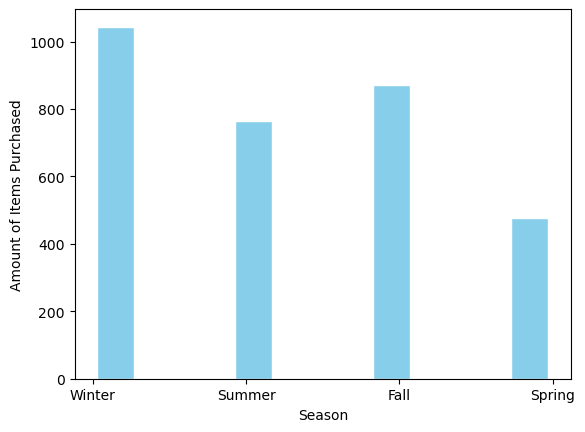

In [ ]:
# Amount of items purcahsed by season
plt.hist(data['Season'], rwidth=0.8, edgecolor='white', color='skyblue')

plt.xlabel('Season')
plt.ylabel('Amount of Items Purchased')
plt.show()

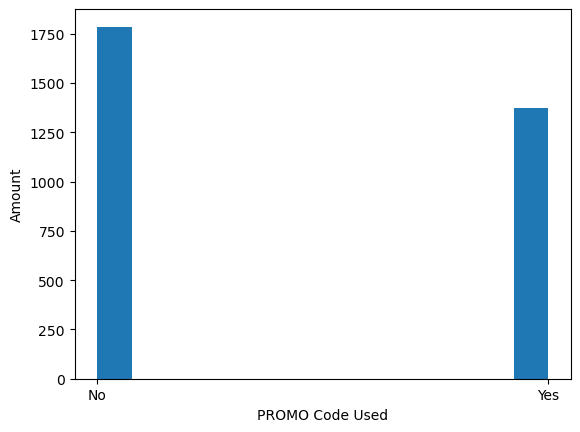

In [ ]:
# Amount of purchases using a PROMO code vs not using one
plt.hist(data['Promo Code Used'], bins='auto')

plt.xlabel('PROMO Code Used')
plt.ylabel("Amount")
plt.show()

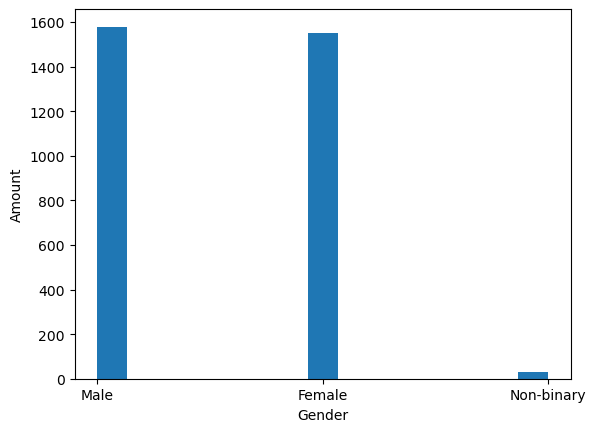

In [ ]:
# Amount spent by gender

plt.hist(data['Gender'], bins='auto')

plt.xlabel('Gender')
plt.ylabel('Amount')
plt.show()